# Task 5: Web Data Extraction & Analysis

## Dataset: Books to Scrape

### Objective
To collect publicly available book information from a website using Python web scraping techniques.

### Purpose
The project extracts structured information such as book titles, prices, ratings, availability, and product URLs. The collected data is cleaned, organized, and analyzed to identify patterns and trends.

## Import the libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## Test the website connection

In [2]:
url = "https://books.toscrape.com/"
response = requests.get(url)

print(response.status_code)

200


## Read the webpage

In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



## Extract the books

In [4]:
books = []

book_items = soup.select("article.product_pod")

for book in book_items:
    title = book.h3.a["title"]
    price = book.select_one(".price_color").text.strip()
    availability = book.select_one(".availability").text.strip()
    
    rating = book.select_one(".star-rating")["class"][1]
    
    books.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability
    })

print(books[:5])

[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three', 'Availability': 'In stock'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One', 'Availability': 'In stock'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One', 'Availability': 'In stock'}, {'Title': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four', 'Availability': 'In stock'}, {'Title': 'Sapiens: A Brief History of Humankind', 'Price': 'Â£54.23', 'Rating': 'Five', 'Availability': 'In stock'}]


## Convert it into a DataFrame

In [5]:
books_df = pd.DataFrame(books)

books_df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [6]:
books_df.shape

(20, 4)

In [7]:
books_df.columns.tolist()

['Title', 'Price', 'Rating', 'Availability']

## Clean the data

In [9]:
books_df["Price"] = (
    books_df["Price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

books_df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [10]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["Rating"] = books_df["Rating"].map(rating_map)

In [11]:
books_df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


## Check data quality

In [12]:
print("Missing values:")
print(books_df.isnull().sum())

print("\nDuplicate rows:")
print(books_df.duplicated().sum())

print("\nData types:")
print(books_df.dtypes)

Missing values:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Duplicate rows:
0

Data types:
Title               str
Price           float64
Rating            int64
Availability        str
dtype: object


## Basic analysis

In [13]:
average_price = books_df["Price"].mean()

print("Average Book Price:", average_price)

Average Book Price: 38.048500000000004


In [14]:
most_expensive = books_df.loc[books_df["Price"].idxmax()]

print(most_expensive)

Title           Our Band Could Be Your Life: Scenes from the A...
Price                                                       57.25
Rating                                                          3
Availability                                             In stock
Name: 15, dtype: object


In [15]:
cheapest = books_df.loc[books_df["Price"].idxmin()]

print(cheapest)

Title           Starving Hearts (Triangular Trade Trilogy, #1)
Price                                                    13.99
Rating                                                       2
Availability                                          In stock
Name: 10, dtype: object


In [16]:
rating_counts = books_df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


## Create visualizations

### Rating distribution

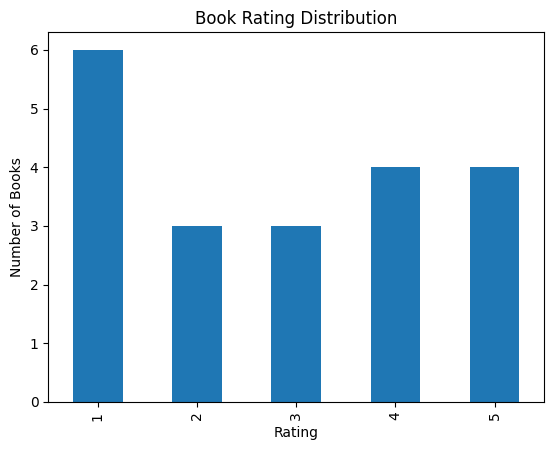

In [18]:
rating_counts.plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

### Price distribution

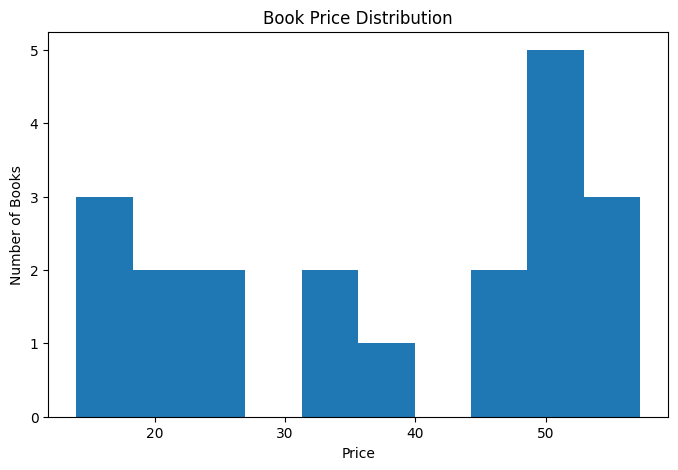

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(books_df["Price"], bins=10)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")

plt.show()

### Rating vs Price

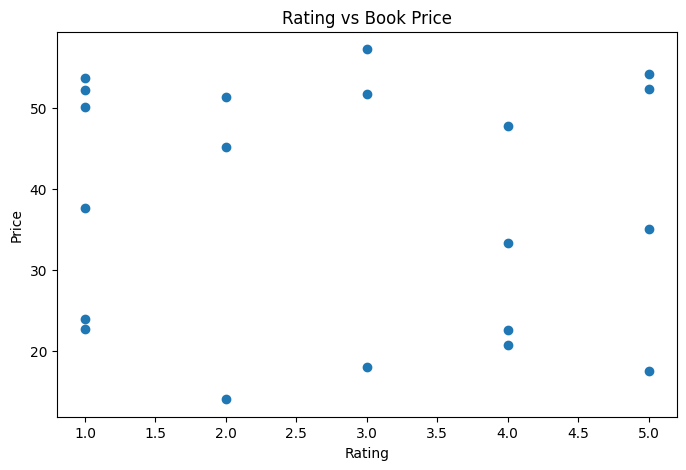

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(books_df["Rating"], books_df["Price"])

plt.title("Rating vs Book Price")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.show()

### Save the dataset

In [23]:
books_df.to_csv("books_data.csv", index=False)

In [24]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'books_data.csv', 'Task5_Web_Scraping.ipynb.ipynb']


# Step 12: Scrape Multiple Pages

To collect a larger dataset, multiple pages of the website are scraped automatically. The extracted information is combined into a single structured dataset.

In [25]:
all_books = []

for page in range(1, 6):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    book_items = soup.select("article.product_pod")
    
    for book in book_items:
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        availability = book.select_one(".availability").text.strip()
        rating = book.select_one(".star-rating")["class"][1]
        
        all_books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

print("Total books collected:", len(all_books))

Total books collected: 100


## Create the final DataFrame

In [26]:
books_df = pd.DataFrame(all_books)

books_df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [27]:
books_df.shape

(100, 4)

## Clean the new dataset

In [29]:
books_df["Price"] = (
    books_df["Price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

In [30]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["Rating"] = books_df["Rating"].map(rating_map)

## Check the final dataset

In [31]:
print("Shape:", books_df.shape)

print("\nMissing values:")
print(books_df.isnull().sum())

print("\nDuplicate rows:")
print(books_df.duplicated().sum())

print("\nData types:")
print(books_df.dtypes)

Shape: (100, 4)

Missing values:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Duplicate rows:
0

Data types:
Title               str
Price           float64
Rating            int64
Availability        str
dtype: object


## Save the final dataset

In [32]:
books_df.to_csv("books_data.csv", index=False)

print("Final dataset saved successfully.")

Final dataset saved successfully.


In [33]:
import os

print(os.path.exists("books_data.csv"))

True


# Step 17: Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of book prices and ratings and identify patterns within the scraped dataset.

## Price statistics

In [36]:
print("Average Price:", books_df["Price"].mean())
print("Minimum Price:", books_df["Price"].min())
print("Maximum Price:", books_df["Price"].max())
print("Median Price:", books_df["Price"].median())

Average Price: 34.560700000000004
Minimum Price: 10.16
Maximum Price: 58.11
Median Price: 34.775000000000006


## Rating distribution

In [35]:
rating_distribution = books_df["Rating"].value_counts().sort_index()

print(rating_distribution)

Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


## Most expensive books

In [37]:
top_expensive = books_df.nlargest(10, "Price")[["Title", "Price", "Rating"]]

top_expensive

,Title,Price,Rating
68,The Death of Humanity: and the Case for Life,58.11,4
40,Slow States of Collapse: Poems,57.31,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
58,The Past Never Ends,56.50,4
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1
91,Masks and Shadows,56.40,2
56,The Secret of Dreadwillow Carse,56.13,1
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1
25,Birdsong: A Story in Pictures,54.64,3
4,Sapiens: A Brief History of Humankind,54.23,5


## Cheapest books

In [38]:
top_cheap = books_df.nsmallest(10, "Price")[["Title", "Price", "Rating"]]

top_cheap

,Title,Price,Rating
84,Patience,10.16,3
20,In Her Wake,12.84,1
81,Princess Between Worlds (Wide-Awake Princess #5),13.34,5
80,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2
92,Mama Tried: Traditional Italian Cooking for th...,14.02,4
88,On a Midnight Clear,14.07,3
47,Untitled Collection: Sabbath Poems 2014,14.27,4
89,Obsidian (Lux #1),14.86,2
85,"Outcast, Vol. 1: A Darkness Surrounds Him (Out...",15.44,4


## Create EDA visualizations

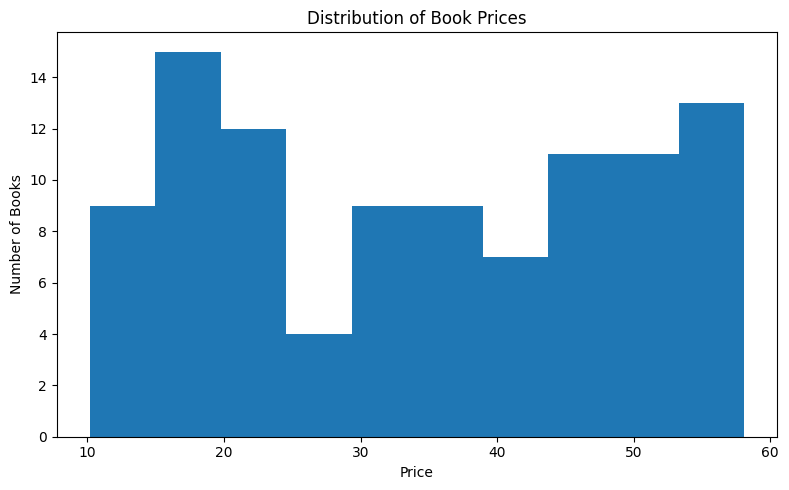

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(books_df["Price"], bins=10)

plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

### Rating distribution

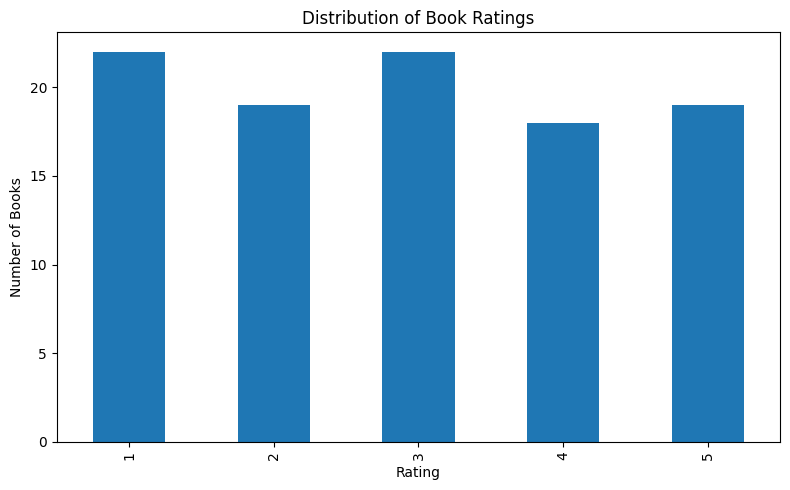

In [41]:
plt.figure(figsize=(8, 5))

rating_distribution.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

### Price vs Rating

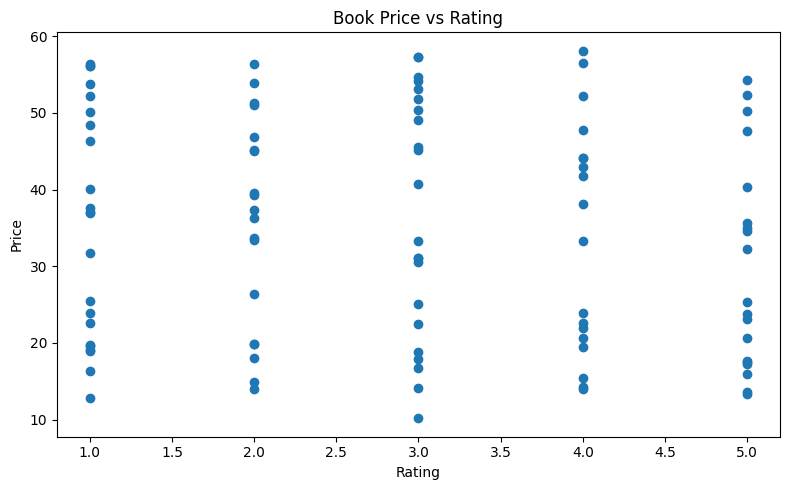

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(books_df["Rating"], books_df["Price"])

plt.title("Book Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Top 10 expensive books

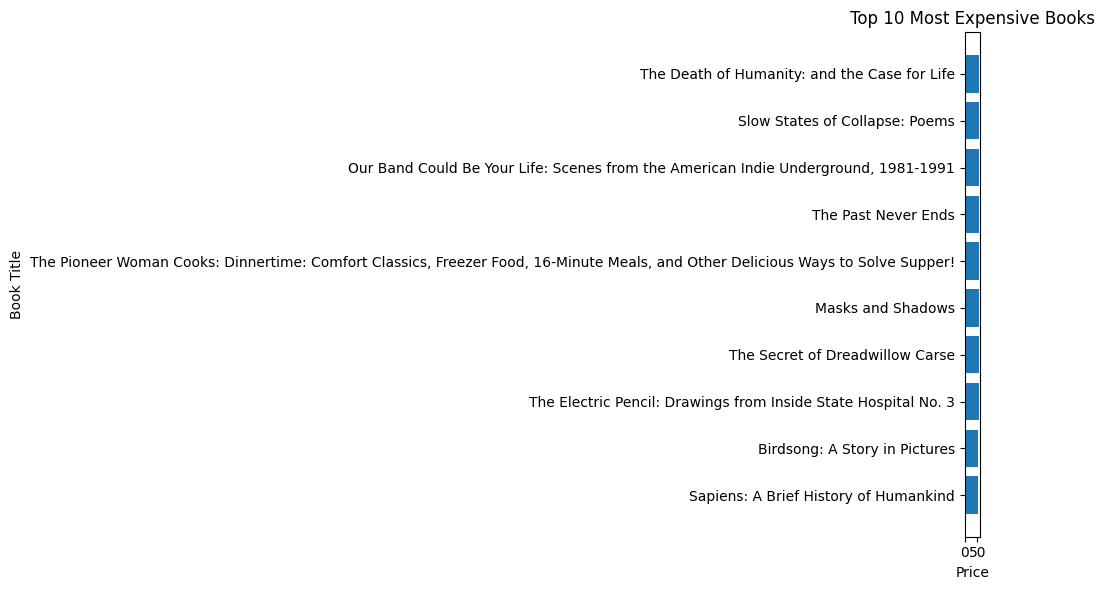

In [43]:
plt.figure(figsize=(10, 6))

top_expensive_sorted = top_expensive.sort_values("Price")

plt.barh(top_expensive_sorted["Title"], top_expensive_sorted["Price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price")
plt.ylabel("Book Title")

plt.tight_layout()
plt.show()

# Step 19: Visual Report

A visual report is created to summarize the major findings from the scraped book dataset.

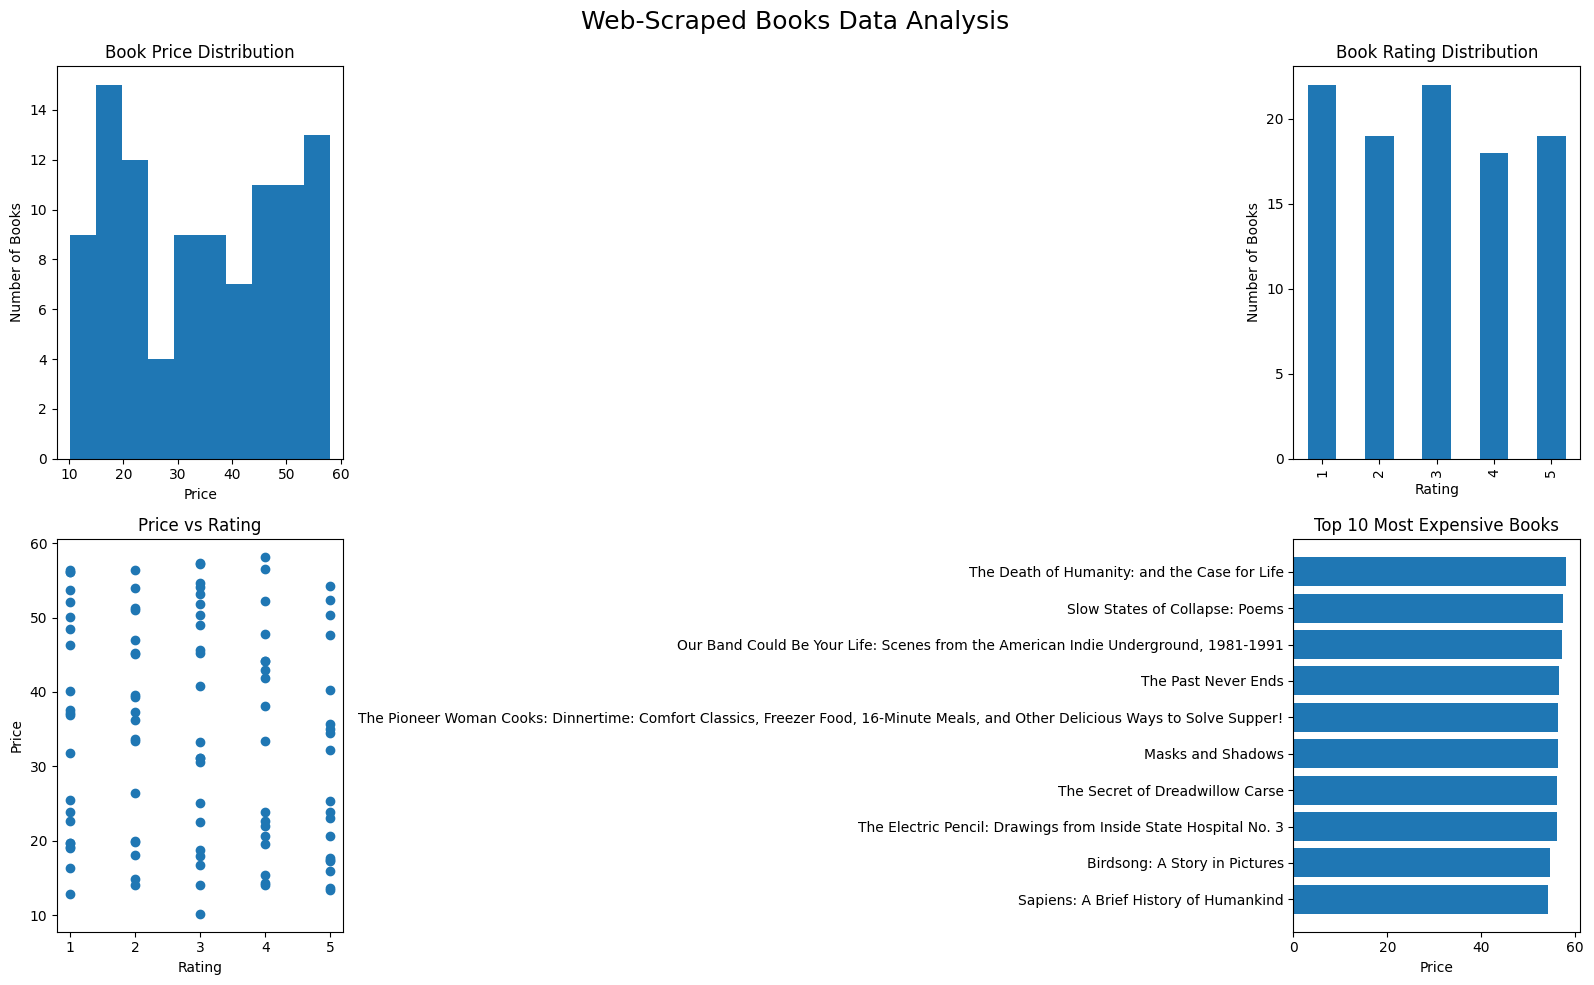

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price distribution
axes[0, 0].hist(books_df["Price"], bins=10)
axes[0, 0].set_title("Book Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Number of Books")

# Rating distribution
rating_distribution.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Book Rating Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Number of Books")

# Price vs Rating
axes[1, 0].scatter(books_df["Rating"], books_df["Price"])
axes[1, 0].set_title("Price vs Rating")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Price")

# Top 10 expensive books
top_expensive_sorted = top_expensive.sort_values("Price")
axes[1, 1].barh(
    top_expensive_sorted["Title"],
    top_expensive_sorted["Price"]
)
axes[1, 1].set_title("Top 10 Most Expensive Books")
axes[1, 1].set_xlabel("Price")

plt.suptitle("Web-Scraped Books Data Analysis", fontsize=18)

plt.tight_layout()
plt.savefig(
    "web_scraping_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
print("Final dataset shape:", books_df.shape)
print("\nColumns:")
print(books_df.columns.tolist())

print("\nFirst 5 rows:")
display(books_df.head())

Final dataset shape: (100, 4)

Columns:
['Title', 'Price', 'Rating', 'Availability']

First 5 rows:


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [46]:
books_df.to_csv("books_data.csv", index=False)

print("books_data.csv saved successfully.")

books_data.csv saved successfully.


In [47]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'books_data.csv', 'Task5_Web_Scraping.ipynb.ipynb', 'web_scraping_report.png']


# Conclusion

The project successfully collected publicly available book data using Python, Requests, and BeautifulSoup. Structured information including book titles, prices, ratings, and availability was extracted from multiple web pages.

The collected data was cleaned and organized into a structured dataset. Exploratory analysis was performed to understand book price distributions, rating patterns, and the relationship between price and rating.

The analysis demonstrates how web scraping can be used to collect real-world data and transform it into useful information for further analysis and decision-making.